### The XOR classifier using Cyclic Projections
This notebook shows the implementation from scratch without the torch abstractions to illustrate how the algorithm works


In [25]:
%load_ext autoreload
%autoreload 2
import sys
import os
import jax.numpy as jnp
import numpy as np
import jax.random as random
import tools.projections as projections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import jax

rand_key = random.key(123)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
### setup problem
NUM_INPUT_BITS = 2
HIDDEN_WIDTH = 8
delta = 1.0 # margin for True label

def make_xor_dataset(num_input_bits):
    num_samples = 2 ** num_input_bits
    indices = jnp.arange(num_samples, dtype=jnp.int32)
    bit_positions = jnp.arange(num_input_bits, dtype=jnp.int32)

    # Shape: (num_input_bits, num_samples)
    X = ((indices[:, None] >> bit_positions) & 1).T
    y = jnp.mod(jnp.sum(X, axis=0), 2)
    return X, y

xor_X, xor_y = make_xor_dataset(NUM_INPUT_BITS)
input_dim = xor_X.shape[0]


# Experiment Parameters
num_trials = 5
BACKWARDS_PASSES = 1000

def forward_pass(W0, W1, x_in):
    x_hidden    = W0 @ x_in
    h_hidden    = jnp.where(x_hidden > 0, x_hidden, 0.1 * x_hidden)  # Leaky ReLU
    x_out       = W1 @ h_hidden

    # Calculate error
    y_target = jnp.atleast_2d(xor_y)
    err1 = jnp.where(y_target == 1, jnp.where(x_out < delta, (x_out - delta)**2, 0), 0)
    err0 = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0), 0)
    batchError = err1 + err0
    return batchError, x_hidden, h_hidden, x_out


## Cyclic projections


In [27]:
### Run Alternating Projections Experiment
results = []
key = rand_key
for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    W0 = random.normal(k1, (HIDDEN_WIDTH, input_dim))

    W1 = random.normal(k2, (1, HIDDEN_WIDTH))

    
    # ------------------------------------------------------------------
    # FORWARD PASS 
    # ------------------------------------------------------------------
    x_in        = xor_X
    y_target = jnp.atleast_2d(xor_y)
    batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)
    
    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 0,
        "Error":     float(current_error),
    })
    
    # ------------------------------------------------------------------
    # BACKWARD PASS
    # ------------------------------------------------------------------
    for i in range(BACKWARDS_PASSES):  # Number of inner projection steps
        # Output layer constraint projection
        x_out, _, _ = projections.classifierOutput(x_out, jnp.eye(1), y_target)

        # Hidden layer matmul projection
        bf = x_out
        h_hidden, W1, x_out = projections.matMul(h_hidden, W1, x_out)
        
        # Activation layer step projection
        x_hidden, _, h_hidden = projections.leakyRelu(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)

        # Input layer matmul projection
        x_in, W0, x_hidden = projections.matMulfixedX(x_in, W0, x_hidden)
        
        # do a logging forward pass to get the current error after projections
        batchError, _, _, _ = forward_pass(W0, W1, xor_X)
            
        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial":     trial,
            "Iteration": i + 1,
            "Error":     float(current_error),
        })
print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Final Error (Last Trial): 1.53e-12


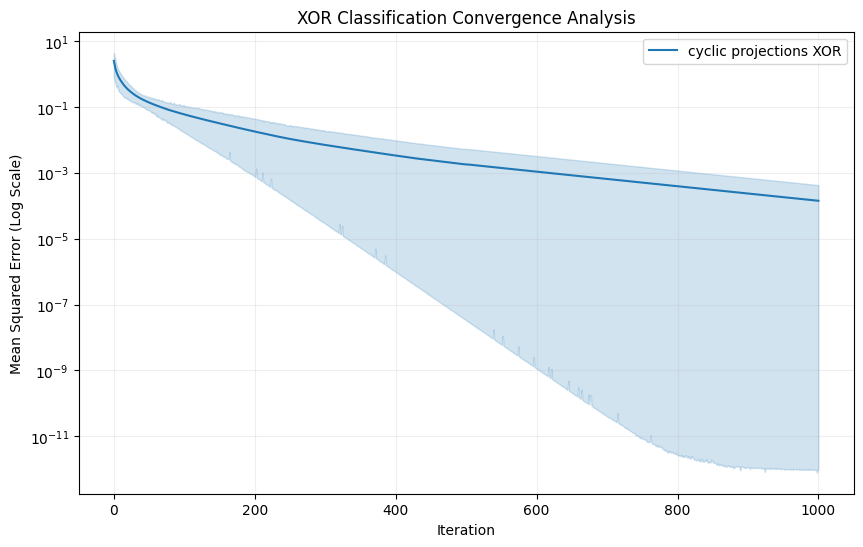

In [28]:
### Visualize Results
df_pure = pd.DataFrame(results.copy())
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pure, x="Iteration", y="Error", label='cyclic projections XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## non linear relaxed projection (weights)

In [29]:
import optax

optim_W0 = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_W1 = optax.sgd(learning_rate=1.0, momentum=0.9)

In [30]:
### Run Alternating Projections Experiment
results = []
key = rand_key
for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    W0 = random.normal(k1, (HIDDEN_WIDTH, input_dim))
    optim_state_W0 = optim_W0.init(W0)

    W1 = random.normal(k2, (1, HIDDEN_WIDTH))
    optim_state_W1 = optim_W1.init(W1)
    
    # ------------------------------------------------------------------
    # FORWARD PASS 
    # ------------------------------------------------------------------
    x_in = xor_X
    y_target = jnp.atleast_2d(xor_y)
    batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)
    
    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 0,
        "Error":     float(current_error),
    })
    
    # ------------------------------------------------------------------
    # BACKWARD PASS
    # ------------------------------------------------------------------
    for i in range(BACKWARDS_PASSES):  # Number of inner projection steps
        # Output layer constraint projection
        x_out, _, _ = projections.classifierOutput(x_out, jnp.eye(1), y_target)

        # Hidden layer matmul projection
        h_hidden, w1_proj, x_out = projections.matMul(h_hidden, W1, x_out)

        pseudo_grads_W1 = W1 - w1_proj
        updates_W1, optim_state_W1 = optim_W1.update(pseudo_grads_W1, optim_state_W1, W1)
        W1 = optax.apply_updates(W1, updates_W1)

        # Activation layer step projection
        x_hidden, _, h_hidden = projections.leakyRelu(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)

        # Input layer matmul projection
        x_in, w0_proj, x_hidden = projections.matMulfixedX(x_in, W0, x_hidden)
        
        pseudo_grads_W0 = W0 - w0_proj
        updates_W0, optim_state_W0 = optim_W0.update(pseudo_grads_W0, optim_state_W0, W0)
        W0 = optax.apply_updates(W0, updates_W0)

        # Do a logging forward pass to get the current error after projections
        batchError, _, _, _ = forward_pass(W0, W1, xor_X)

        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial":     trial,
            "Iteration": i + 1,
            "Error":     float(current_error),
        })
print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Final Error (Last Trial): 2.58e-14


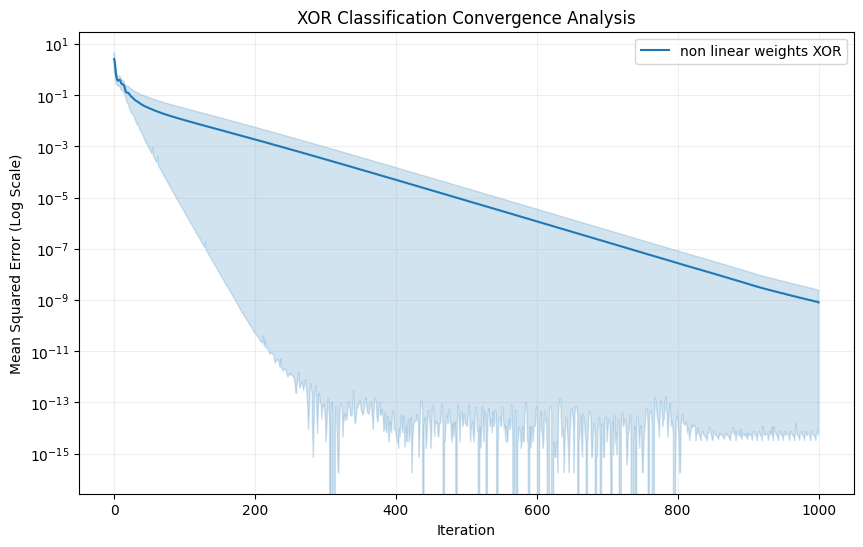

In [31]:
### Visualize Results
df_non_linear_weights = pd.DataFrame(results.copy())
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_non_linear_weights, x="Iteration", y="Error", label='non linear weights XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## nonlinear relaxed projection (full)

In [32]:
import optax

optim_W0 = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_W1 = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_h_hidden = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_x_hidden = optax.sgd(learning_rate=1.0, momentum=0.9)



In [33]:
### Run Alternating Projections Experiment
results = []
key = rand_key
for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    W0 = random.normal(k1, (HIDDEN_WIDTH, input_dim))
    optim_state_W0 = optim_W0.init(W0)

    W1 = random.normal(k2, (1, HIDDEN_WIDTH))
    optim_state_W1 = optim_W1.init(W1)
    
    # ------------------------------------------------------------------
    # FORWARD PASS 
    # ------------------------------------------------------------------
    x_in = xor_X
    y_target = jnp.atleast_2d(xor_y)
    batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)
    
    optim_state_x_hidden = optim_x_hidden.init(x_hidden)
    optim_state_h_hidden = optim_h_hidden.init(h_hidden)

    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 0,
        "Error":     float(current_error),
    })
    
    # ------------------------------------------------------------------
    # BACKWARD PASS
    # ------------------------------------------------------------------
    for i in range(BACKWARDS_PASSES):  # Number of inner projection steps
        # Output layer constraint projection
        x_out, _, _ = projections.classifierOutput(x_out, jnp.eye(1), y_target)

        # Hidden layer matmul projection
        h_hidden_proj, w1_proj, x_out = projections.matMul(h_hidden, W1, x_out)
        
        pseudo_grads_W1 = W1 - w1_proj
        updates_W1, optim_state_W1 = optim_W1.update(pseudo_grads_W1, optim_state_W1, W1)
        W1 = optax.apply_updates(W1, updates_W1)
        
        pseudo_grads_h_hidden = h_hidden - h_hidden_proj
        updates_h_hidden, optim_state_h_hidden = optim_h_hidden.update(pseudo_grads_h_hidden, optim_state_h_hidden, h_hidden)
        h_hidden = optax.apply_updates(h_hidden, updates_h_hidden)

        # Activation layer step projection
        x_hidden_proj, _, h_hidden_proj = projections.leakyRelu(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
        
        pseudo_grads_h_hidden = h_hidden - h_hidden_proj
        updates_h_hidden, optim_state_h_hidden = optim_h_hidden.update(pseudo_grads_h_hidden, optim_state_h_hidden, h_hidden)
        h_hidden = optax.apply_updates(h_hidden, updates_h_hidden)

        pseudo_grads_x_hidden = x_hidden - x_hidden_proj
        updates_x_hidden, optim_state_x_hidden = optim_x_hidden.update(pseudo_grads_x_hidden, optim_state_x_hidden, x_hidden)
        x_hidden = optax.apply_updates(x_hidden, updates_x_hidden)

        # Input layer matmul projection
        x_in, w0_proj, x_hidden_proj = projections.matMulfixedX(x_in, W0, x_hidden)
        
        pseudo_grads_W0 = W0 - w0_proj
        updates_W0, optim_state_W0 = optim_W0.update(pseudo_grads_W0, optim_state_W0, W0)
        W0 = optax.apply_updates(W0, updates_W0)

        pseudo_grads_x_hidden = x_hidden - x_hidden_proj
        updates_x_hidden, optim_state_x_hidden = optim_x_hidden.update(pseudo_grads_x_hidden, optim_state_x_hidden, x_hidden)
        x_hidden = optax.apply_updates(x_hidden, updates_x_hidden)

        # Do a logging forward pass to get the current error after projections
        batchError, _, _, _ = forward_pass(W0, W1, xor_X)

        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial":     trial,
            "Iteration": i + 1,
            "Error":     float(current_error),
        })
print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Final Error (Last Trial): 0.00e+00


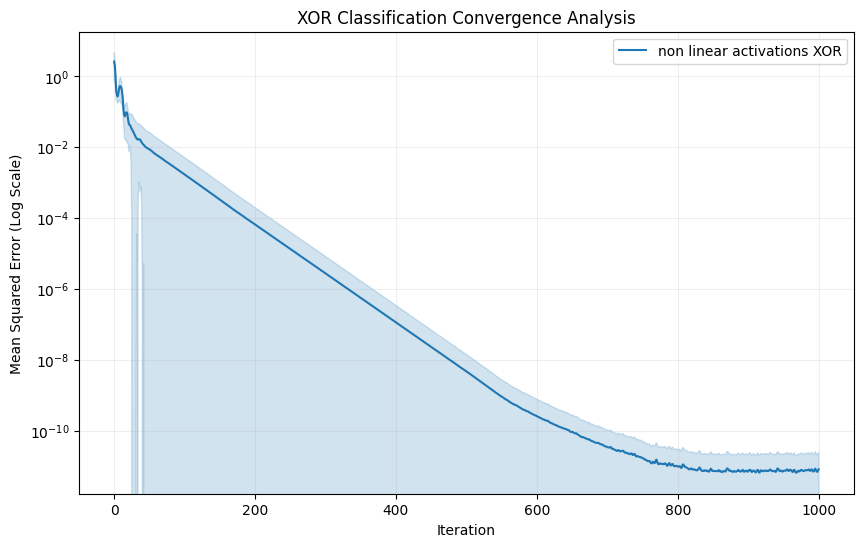

In [34]:
### Visualize Results
df_non_linear_activations = pd.DataFrame(results.copy())
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_non_linear_activations, x="Iteration", y="Error", label='non linear activations XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## non linear relaxation (weights) with forward


In [35]:
optim_W0 = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_W1 = optax.sgd(learning_rate=1.0, momentum=0.9)


In [36]:
### Run Alternating Projections Experiment
results = []
key = rand_key
for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    W0 = random.normal(k1, (HIDDEN_WIDTH, input_dim))
    optim_state_W0 = optim_W0.init(W0)

    W1 = random.normal(k2, (1, HIDDEN_WIDTH))
    optim_state_W1 = optim_W1.init(W1)
    
    # ------------------------------------------------------------------
    # FORWARD PASS 
    # ------------------------------------------------------------------
    x_in = xor_X
    y_target = jnp.atleast_2d(xor_y)
    batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)
    
    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 0,
        "Error":     float(current_error),
    })
    
    # ------------------------------------------------------------------
    # BACKWARD PASS
    # ------------------------------------------------------------------
    for i in range(BACKWARDS_PASSES):  # Number of inner projection steps
        # Output layer constraint projection
        x_out, _, _ = projections.classifierOutput(x_out, jnp.eye(1), y_target)

        # Hidden layer matmul projection
        h_hidden, w1_proj, x_out = projections.matMul(h_hidden, W1, x_out)
        pseudo_grads_W1 = W1 - w1_proj
        updates_W1, optim_state_W1 = optim_W1.update(pseudo_grads_W1, optim_state_W1, W1)
        W1 = optax.apply_updates(W1, updates_W1)

        # Activation layer step projection
        x_hidden, _, h_hidden = projections.leakyRelu(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)

        # Input layer matmul projection
        x_in, w0_proj, x_hidden = projections.matMulfixedX(x_in, W0, x_hidden)
        pseudo_grads_W0 = W0 - w0_proj
        updates_W0, optim_state_W0 = optim_W0.update(pseudo_grads_W0, optim_state_W0, W0)
        W0 = optax.apply_updates(W0, updates_W0)

        # Do a logging forward pass to get the current error after projections
        batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)

        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial":     trial,
            "Iteration": i + 1,
            "Error":     float(current_error),
        })
print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Final Error (Last Trial): 0.00e+00


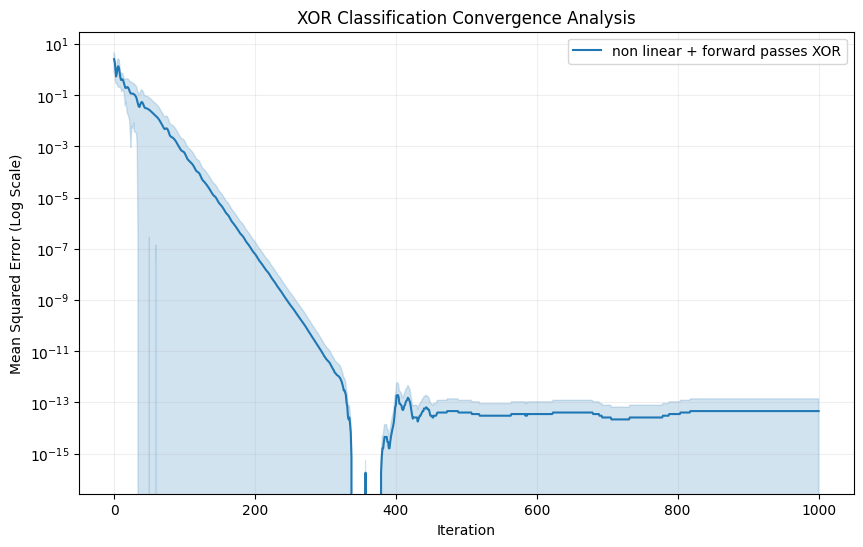

In [37]:
### Visualize Results
df_non_linear_with_forward = pd.DataFrame(results.copy())
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_non_linear_with_forward, x="Iteration", y="Error", label='non linear + forward passes XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [ ]:
df_pure['method'] = 'Cyclic Projections'
df_non_linear_weights['method'] = 'Non Linear Projections (Weights Only)'
df_non_linear_activations['method'] = 'Non Linear Projections (with Activations)'
df_non_linear_with_forward['method'] = 'Non Linear Projections (Weights + Forward Passes)'

# Merge vertically
df_full = pd.concat([df_pure, df_non_linear_weights, df_non_linear_activations, df_non_linear_with_forward], ignore_index=True)

## plot 
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_full, x="Iteration", y="Error", hue="method")
plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()
